# Replication of Fig. 2 (SSP path-independence) for four GCMs

Reproduces Figure 2 of the BCD-ME preprint using the authors' exact method
(`figure_ssps_gwls.ipynb`), restricted to four models: **CanESM5, MIROC6,
MPI-ESM1-2-LR, IPSL-CM6A-LR**.

Per-region change in the 20-year mean of daily near-surface T from GWL0.61
to GWL2, split by SSP (245 / 370 / 585), for matched initial-condition runs.
If the SSP boxes overlap within a region, regional summary statistics are
(near) independent of the emissions pathway at a fixed warming level.

**Deviations from authors:** (1) four models instead of the full set; (2)
landmask from Natural Earth (regionmask) in place of the Carleton
impact-region shapefile, which is unavailable here — affects only coastal
cells. Everything else (member balancing, ERA5, matched-run `dropna`, xagg to
IPCC-WGI v4 regions, 5-biggest+5-smallest sort) follows the authors.

Run with the Python-3.12 env (`.venv312`: arraylake 1.x + xagg + matplotlib).
`ARRAYLAKE_TOKEN` must be set.

In [1]:
import os, re, string, warnings
import numpy as np, pandas as pd, xarray as xr
import geopandas as gpd, xagg as xa, regionmask
import arraylake, zarr
from matplotlib import pyplot as plt
from matplotlib import patches as mpatches
warnings.filterwarnings('ignore')

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters and paths

In [2]:
AUX = '/burg-archive/home/mck2199/summer/summer_data/aux/'
FIGDIR = '/burg/glab/users/mck2199/summer_data/figures/'
POLY_FN = AUX + 'geo_data/IPCC-WGI-reference-regions-v4.shp'
CACHE = AUX + 'diagnostics/gwl_test_data_gwl2_faithful.nc'        # post-xagg (regional)
RAWCACHE = AUX + 'diagnostics/gwl_test_rawchange_gwl2_faithful.nc'  # pre-xagg (per-gridcell)
os.makedirs(AUX + 'diagnostics', exist_ok=True)

VAR, GWL = 'tas', 2
MODELS = ['CanESM5', 'MIROC6', 'MPI-ESM1-2-LR', 'IPSL-CM6A-LR']  # our four (None = full set)
EXPS = ['ssp245', 'ssp370', 'ssp585']
COLORS = {'ssp245': '#f69320', 'ssp370': '#df0000', 'ssp585': '#980002'}

## WG1 reference regions

IPCC-WGI v4 reference regions, dropping ocean regions and E/W Antarctica
(authors' cell 3). Download the shapefile if absent.

In [3]:
if not os.path.exists(POLY_FN):
    z = AUX + 'IPCC-WGI-reference-regions-v4_shapefile.zip'
    os.system('wget https://github.com/IPCC-WG1/Atlas/raw/refs/heads/main/'
              'reference-regions/IPCC-WGI-reference-regions-v4_shapefile.zip -P ' + AUX)
    os.system(f'unzip {z} -d {AUX}geo_data/')

gdf = gpd.read_file(POLY_FN)
gdf = gdf.query('Type != "Ocean" and Acronym != "EAN" and Acronym != "WAN"')
gdf.head()

,Continent,Type,Name,Acronym,geometry
0,POLAR,Land,Greenland/Iceland,GIC,"POLYGON ((-10 62, -10.4375 62, -10.875 62, -11..."
1,NORTH-AMERICA,Land,N.W.North-America,NWN,"POLYGON ((-105 50, -105.4386 50, -105.87719 50..."
2,NORTH-AMERICA,Land,N.E.North-America,NEN,"POLYGON ((-50 50, -50.44 50, -50.88 50, -51.32..."
3,NORTH-AMERICA,Land,W.North-America,WNA,"POLYGON ((-130 50, -129.5614 50, -129.12281 50..."
4,NORTH-AMERICA,Land,C.North-America,CNA,"POLYGON ((-90 50, -90 49.5614, -90 49.12281, -..."


In [4]:
def get_landmask(ds_grid):
    """Substitute for authors' Carleton get_landmask: Natural Earth land -> 1/0."""
    land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
    m = land.mask(ds_grid.lon, ds_grid.lat)        # 0 on land, NaN ocean
    return xr.where(~np.isnan(m), 1, 0)

## Load BCD-ME data

In [5]:
# Start ArrayLake client, open read-only session to the bias-corrected repo
al_client = arraylake.Client()
repo = al_client.get_repo('ClimateUncertaintyLab/bcd_me_qdm')
session = repo.readonly_session(branch='main')

modlist = list(zarr.open_group(session.store, mode='r').group_keys())
if MODELS is not None:
    modlist = [m for m in modlist if m in MODELS]
print('models:', modlist)

models: ['CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'MIROC6']


In [6]:
# Landmask on the uniform 1-deg grid
ds_grid = xr.open_zarr(session.store, zarr_format=3, group=modlist[0])[['lat', 'lon']]
landmask = get_landmask(ds_grid)

In [7]:
# Which models / runs have data (authors' cell 9)
has_data_all = [xr.open_zarr(session.store, zarr_format=3, group=m) for m in modlist]
has_data_all = [hd.has_data for hd in has_data_all if 'has_data' in hd]
has_data_all = xr.concat(has_data_all, dim='idv', join='outer').load()
has_data_all = has_data_all.where(~np.isnan(has_data_all), 0)

### Member selection: matched initial-condition runs

The authors balance to an equal number of runs per experiment, then keep
only `(model, run)` pairs present under every experiment (`dropna(how='any')`
after aggregation). With the full ensemble the first-N balancing already
yields matched runs; on our smaller four-model pull we enforce the
intersection up front so multiple models survive. IPSL-CM6A-LR has runs in
each SSP but no single run id shared across all three, so it contributes
zero matched members and drops out — by the method, not by hand.

In [8]:
htmp = has_data_all.sel(gwl=GWL, variable=VAR)
htmp = htmp.where(htmp, drop=True)
htmp = htmp.set_index(idv=['model', 'experiment', 'run']).to_dataframe().reset_index()
htmp = htmp[htmp.experiment.isin(EXPS)]
# keep (model, run) present in ALL target experiments
nexp = htmp.groupby(['model', 'run'])['experiment'].transform('nunique')
subset = htmp[nexp == len(EXPS)][['model', 'experiment', 'run']]
keys = subset.set_index(['model', 'experiment', 'run']).index
print(subset.groupby(['model', 'experiment']).size())

model          experiment
CanESM5        ssp245        15
               ssp370        15
               ssp585        15
MIROC6         ssp245         3
               ssp370         3
               ssp585         3
MPI-ESM1-2-LR  ssp245        10
               ssp370        10
               ssp585        10
dtype: int64


### Load matched members, compute the GWL change

ERA5-corrected daily T, land-masked, averaged over the 20-year window at each
GWL (`mean` over `dayofyear`,`year`); change = stat(GWL2) − stat(GWL0.61).
Uses the cached result if present, otherwise pulls from zarr (~20 min).

In [9]:
def build_change():
    dss = []
    for mod in keys.levels[0]:
        k = keys[keys.get_loc(mod)]
        if len(k) == 0:
            continue
        ds = (xr.open_zarr(session.store, zarr_format=3, group=mod)
              .set_index(idv=['model', 'experiment', 'run'])
              .sel(idv=k, gwl=[0.61, GWL], proj_base='ERA5'))[[VAR]]
        ds = ds.where(landmask)
        stats = ds.mean(('dayofyear', 'year'), skipna=False).rename({VAR: VAR + 'mean'})
        dss.append(stats.load())
        print(f'  loaded {mod}: {len(k)} members')
    dss = xr.concat(dss, dim='idv')
    ddss = dss.sel(gwl=GWL) - dss.sel(gwl=0.61)
    ddss.reset_index('idv').to_netcdf(RAWCACHE, engine='h5netcdf')   # persist per-gridcell change
    return ddss


def add_bnds(d):
    """Precompute lat/lon cell bounds so xagg.get_bnds returns early
    (avoids its in-place edge mutation, which fails on read-only index coords)."""
    d = d.copy()
    for var in ['lat', 'lon']:
        c = d[var]
        diff = c.diff(var)
        diff = xr.concat([xr.DataArray([diff[0].values], coords={var: [c[0].values]}, dims=var),
                          diff], dim=var)
        b = xr.concat([c - 0.5 * diff, c + 0.5 * diff], dim='bnds').transpose(var, 'bnds')
        b = (b.where(b <= 180, b - 360).where(b >= -180, b + 360)) if var == 'lon' \
            else (b.where(b <= 90, 90).where(b >= -90, -90))
        d[var + '_bnds'] = b
    return d


def aggregate(ddss):
    """xagg pixel-overlap aggregate to WGI regions (authors' cell 10)."""
    ddss = add_bnds(ddss)
    wm = xa.pixel_overlaps(ddss, gdf)
    agg = xa.aggregate(ddss, wm)
    out = agg.to_dataset()
    for v in ['model', 'experiment', 'run']:
        out = out.assign_coords({v: (('idv'), ddss[v].values)})
    out = out.set_index(idv=['model', 'experiment', 'run']).unstack()
    out = out.stack(idv=['model', 'run']).dropna('idv', how='all')
    out.reset_index('idv').to_netcdf(CACHE, engine='h5netcdf')
    return out

In [10]:
if os.path.exists(CACHE):
    ddss_out = xr.open_dataset(CACHE).set_index(idv=['model', 'run'])
elif os.path.exists(RAWCACHE):
    ddss_out = aggregate(xr.open_dataset(RAWCACHE))
else:
    ddss_out = aggregate(build_change())

ddss_out = ddss_out.dropna('idv')   # authors' how='any'; matched members already enforced
print('matched members:', ddss_out.sizes['idv'],
      '| models:', sorted(set(str(m) for m in ddss_out.model.values)))

  loaded CanESM5: 45 members


  loaded MIROC6: 9 members


  loaded MPI-ESM1-2-LR: 30 members


creating polygons for each pixel...


calculating overlaps between pixels and output polygons...


success!
aggregating tasmean...


all variables aggregated to polygons!


matched members: 28 | models: ['CanESM5', 'MIROC6', 'MPI-ESM1-2-LR']


## Regionally aggregated diagnostic figure

Regions sorted by the largest pairwise inter-SSP difference of regional means;
the 5 biggest and 5 smallest are shown (authors' cell 13). Only the
mean panel is reproduced here.

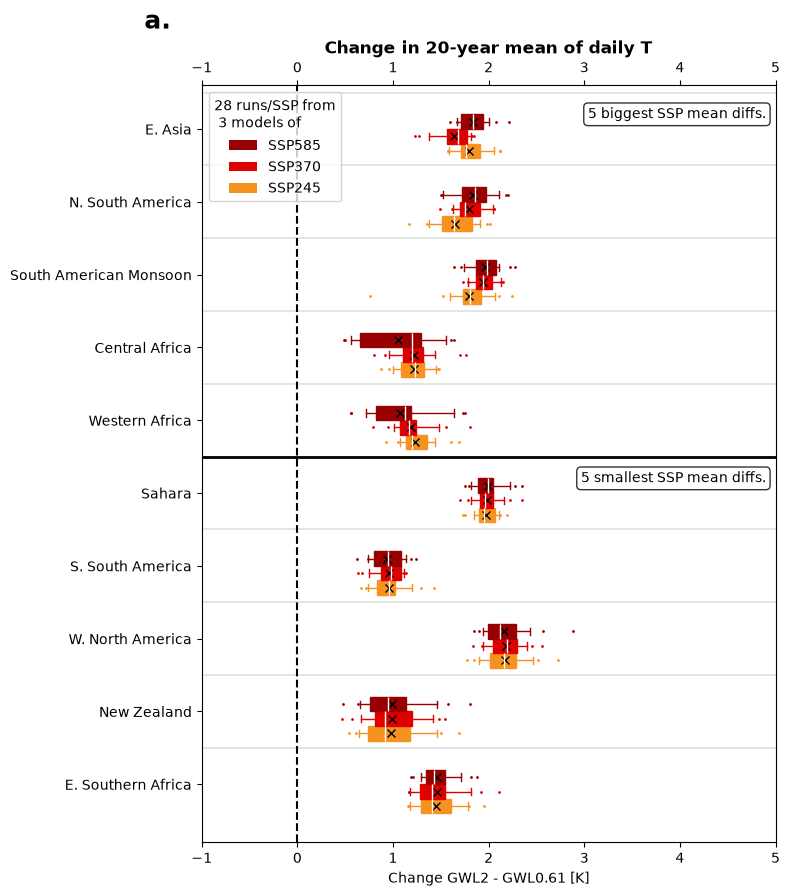

In [11]:
METRICS = {'tasmean': ('20-year mean of daily T', 'K', [-1, 5])}
BW, SHOW = 0.2, 5
valid = ddss_out['tasmean'].sel(experiment=EXPS).notnull().any('poly_idx')
nruns = max(int(valid.sel(experiment=e).sum()) for e in EXPS)
nmods = len(np.unique([str(m) for m in ddss_out.model.values]))
run_desc = f'{nruns} runs/SSP from\n {nmods} models'

fig = plt.figure(figsize=(8, 9))
axs = [fig.add_subplot(1, 1, 1)]

for vi, var in enumerate(METRICS):
    pdata = ddss_out[var].sel(experiment=EXPS)
    # sort regions by max pairwise |mean_i - mean_j| across SSPs
    diffs, labels = [], []
    for e1 in pdata.experiment.values:
        for e2 in pdata.experiment.values:
            diffs.append(np.abs(pdata.sel(experiment=e1).mean('idv')
                                - pdata.sel(experiment=e2).mean('idv'))
                         .drop_vars('experiment', errors='ignore'))
            labels.append(f'{e1}-{e2}')
    diffs = xr.concat(diffs, dim=pd.Index(labels, name='diffexps'))
    ds_sorted = diffs.max('diffexps').sortby(diffs.max('diffexps'), ascending=False).dropna('poly_idx')
    poly_locs = np.r_[ds_sorted.poly_idx.values[:SHOW], ds_sorted.poly_idx.values[-SHOW:]][::-1]

    ax = axs[vi]
    for ri, reg in enumerate(poly_locs):
        for ei, exp in enumerate(pdata.experiment.values):
            d = pdata.sel(experiment=exp, poly_idx=reg)
            d = d[~np.isnan(d)]
            if len(d) == 0:
                continue
            pos = ri - 1.5 * BW + BW * ei
            bp = ax.boxplot(d, positions=[pos], patch_artist=True, widths=BW,
                            whis=[5, 95], flierprops={'marker': '.', 'markersize': 2},
                            orientation='horizontal')
            for it in ['boxes', 'whiskers', 'fliers', 'caps']:
                plt.setp(bp[it], color=COLORS[exp])
            plt.setp(bp['boxes'], facecolor=COLORS[exp])
            plt.setp(bp['medians'], color='white')
            plt.setp(bp['fliers'], markeredgecolor=COLORS[exp])
            ax.plot([d.mean()], [pos], '-x', color='k')
        ax.axhline(ri + 0.5, color='grey', linewidth=0.3)
    ax.axvline(0, color='k', linestyle='--')
    ax.set_yticks(range(len(poly_locs)),
                  labels=[re.sub(r'\&', ' & ', re.sub(r'\.', '. ', re.sub(r'\-', ' ', t)))
                          for t in ddss_out.Name.sel(poly_idx=poly_locs).values])
    ax.tick_params(axis='x', labeltop=True, top=True)
    ax.set_xlim(METRICS[var][2])
    ax.axhline(SHOW - 1 + 0.5, color='k', linewidth=2)
    if vi == 0:
        xmax = ax.get_xlim()[1]
        for text, yt in zip([f'{SHOW} biggest SSP mean diffs.', f'{SHOW} smallest SSP mean diffs.'],
                            [SHOW * 2 - 1 - 0.2, SHOW - 1 - 0.2]):
            ax.text(xmax - 0.1, yt + 0.5, text, ha='right', va='top', fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.3', fc='w', ec='k', alpha=0.8))
        ax.legend(handles=[mpatches.Patch(facecolor=COLORS[e], label=e.upper())
                           for e in pdata.experiment.values][::-1],
                  loc='upper left', title=run_desc + ' of')
    ax.set_title(f'Change in {METRICS[var][0]}', fontweight='bold')
    ax.set_xlabel(f'Change GWL{GWL} - GWL0.61 [{METRICS[var][1]}]')
    ax.text(-0.1, 1.1, string.ascii_lowercase[vi] + '.', transform=ax.transAxes,
            ha='left', va='top', fontsize=18, fontweight='bold')

plt.tight_layout()
os.makedirs(FIGDIR, exist_ok=True)
plt.savefig(FIGDIR + 'bcdme_fig2_faithful.png', dpi=150, bbox_inches='tight')
plt.show()